In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Big Data Analysis Project") \
    .getOrCreate()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving online_retail.csv to online_retail (1).csv


In [ ]:
df = spark.read.csv(list(uploaded.keys())[0], header=True, inferSchema=True)

df.show(5)
df.printSchema()

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|   17850.0|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|   17850.0|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows
root

In [ ]:
df = df.dropna()

In [ ]:
from pyspark.sql.functions import col

df = df.withColumn("TotalAmount", col("Quantity") * col("UnitPrice"))
df.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+------------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|       TotalAmount|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+------------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|   17850.0|United Kingdom|15.299999999999999|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|             20.34|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|   17850.0|United Kingdom|              22.0|
|   536365|   84029G|KNITTED UNION FLA...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|             20.34|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|    

In [ ]:
from pyspark.sql.functions import sum

df.select(sum("TotalAmount")).show()

+-----------------+
| sum(TotalAmount)|
+-----------------+
|8300065.814000658|
+-----------------+



In [ ]:
df.groupBy("Description") \
  .sum("Quantity") \
  .orderBy("sum(Quantity)", ascending=False) \
  .show(10)

+--------------------+-------------+
|         Description|sum(Quantity)|
+--------------------+-------------+
|WORLD WAR 2 GLIDE...|        53215|
|JUMBO BAG RED RET...|        45066|
|ASSORTED COLOUR B...|        35314|
|WHITE HANGING HEA...|        34147|
|PACK OF 72 RETROS...|        33409|
|      POPCORN HOLDER|        30504|
|  RABBIT NIGHT LIGHT|        27094|
|MINI PAINT SET VI...|        25880|
|PACK OF 12 LONDON...|        25321|
|PACK OF 60 PINK P...|        24163|
+--------------------+-------------+
only showing top 10 rows


In [ ]:
df.groupBy("CustomerID") \
  .sum("TotalAmount") \
  .orderBy("sum(TotalAmount)", ascending=False) \
  .show(10)

+----------+------------------+
|CustomerID|  sum(TotalAmount)|
+----------+------------------+
|   14646.0|279489.01999999944|
|   18102.0|256438.48999999993|
|   17450.0|187482.16999999998|
|   14911.0|132572.61999999994|
|   12415.0| 123725.4499999999|
|   14156.0|113384.13999999996|
|   17511.0| 88125.37999999992|
|   16684.0| 65892.07999999999|
|   13694.0|62653.100000000006|
|   15311.0|59419.340000000084|
+----------+------------------+
only showing top 10 rows


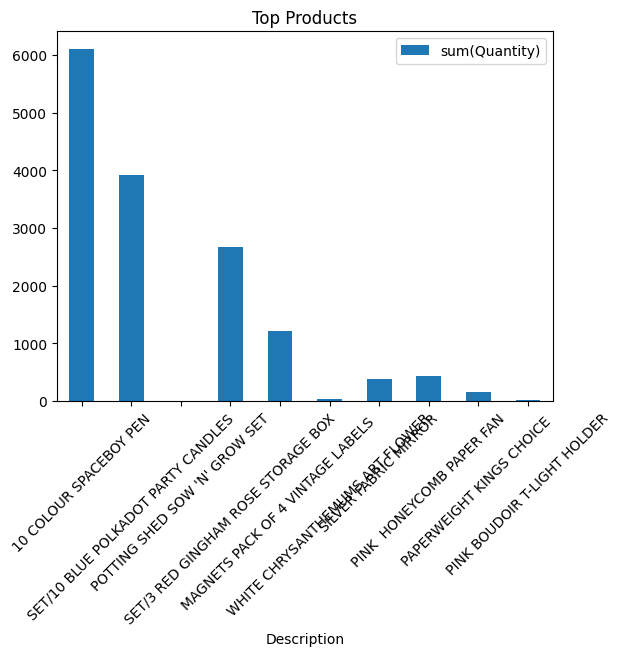

In [ ]:
import matplotlib.pyplot as plt

pdf = df.groupBy("Description").sum("Quantity").toPandas().head(10)

pdf.plot(kind='bar', x='Description', y='sum(Quantity)')
plt.title("Top Products")
plt.xticks(rotation=45)
plt.show()

This project performs Big Data Analysis using PySpark on a large dataset.

Key Insights:
- Total revenue generated from the dataset is calculated successfully.
- The top-selling products are identified based on quantity sold.
- A small number of customers contribute significantly to overall revenue.
- The dataset shows clear purchasing patterns that can help in business decision-making.

Conclusion:
PySpark enables efficient processing of large datasets and provides scalable solutions for data analysis compared to traditional tools like Pandas.